<a href="https://colab.research.google.com/github/liminalvoid/nlp/blob/main/sem_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 7. Fine-tuning BERT

## Установка, импорт библиотек и базовые настройки

In [1]:
%pip -q install -U transformers datasets evaluate accelerate seqeval scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 70.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 19.5 MB/s eta 0:00:00


In [2]:
import os
import random

import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModelForTokenClassification,
    DataCollatorWithPadding,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)


SEED = 42

set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("device:", device)
if torch.cuda.is_available():
    print("GPU model:", torch.cuda.get_device_name(0))

device: cuda
GPU model: Tesla T4


## Sequence classification

В качестве исходного датасета используется набор данных для классификации новостных текстов на русском ([data-silence/rus_news_classifiera](https://huggingface.co/datasets/data-silence/rus_news_classifier)).

In [3]:
dataset_name = "data-silence/rus_news_classifier"
dataset = load_dataset(dataset_name)

print(dataset)

for split in ["train", "test"]:
    print(f"\n--- {split} examples ---")

    for i in range(3):
        example = dataset[split][i]

        print(
            f"[{i}] sentence = {example["news"]}"
            f"    label    = {example["labels"]}"
        )

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/69.1M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/17.3M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/57530 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/14383 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news', 'labels'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels'],
        num_rows: 14383
    })
})

--- train examples ---
[0] sentence = Житель Москвы сходил на сеанс эротического массажа, после которого умер. Об этом сообщает Telegram-канал Mash. По информации издания, 31-летний москвич заказывал сеанс массажа с последующими интимными услугами в квартире на бульваре Яна Райниса. Через некоторое время тело мужчины обнаружили в ванной. Жители дома рассказали полиции, что квартира сдавалась посуточно, и в ней регулярно проходили не только аналогичные сеансы, но и вечеринки, сообщает канал. Точную причину смерти москвича определят следователи. Ранее трое жителей Чечни, чьи личности не раскрываются, пропали после оргии в Грозном. Во время вечеринки компания из четырех человек активно снимала видео, в том числе процесс употребления неизвестного порошка.    label    = 1
[1] sentence = В 2021 год

Ниже представлена токенизация и препроцессинг исходного корпуса.

In [5]:
model_checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
preprocess = lambda batch: tokenizer(
    batch["news"],
    truncation=True,
    max_length=128,
)

tokenized_dataset = dataset.map(preprocess, batched=True)

tokenized_dataset

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/57530 [00:00<?, ? examples/s]

Map:   0%|          | 0/14383 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['news', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 57530
    })
    test: Dataset({
        features: ['news', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 14383
    })
})

Загрузка BERT с classification head и вывод модели.

In [6]:
label2id = {
    "climate": 0,
    "conflicts": 1,
    "culture": 2,
    "economy": 3,
    "gloss": 4,
    "health": 5,
    "politics": 6,
    "science": 7,
    "society": 8,
    "sports": 9,
    "travel": 10,
}
id2label = {v: k for k, v in label2id.items()}

model = AutoModelForSequenceClassification.from_pretrained(
    model_checkpoint,
    num_labels=len(label2id),
    id2label=id2label,
    label2id=label2id,
)

print(model)
print("\nClassifier head:")
print(model.classifier)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12,

Метрики для оценки результата.

In [43]:
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")


def calculate_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(
        predictions=preds,
        references=labels,
    )["accuracy"]
    f1 = f1_metric.compute(
        predictions=preds,
        references=labels,
        average="weighted",
    )["f1"]

    return {"accuracy": acc, "f1": f1}

Fine-tuning на исходном датасете.

In [38]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

selected_range = range(800)
train_dataset = tokenized_dataset["train"].select(selected_range)
test_dataset = tokenized_dataset["test"].select(selected_range)

steps_per_epoch = len(train_dataset) // 16
eval_steps = 5

print("Приблизительное количество шагов за эпоху:", steps_per_epoch)
print("Валидация каждые", eval_steps, "шагов")

training_args = TrainingArguments(
    output_dir="output",
    eval_strategy="steps",
    eval_steps=eval_steps,
    save_strategy="steps",
    save_steps=eval_steps,
    logging_strategy="steps",
    logging_steps=1,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=2,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    report_to="none",
    disable_tqdm=True,
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=calculate_metrics,
)

trainer.train()

Приблизительное количество шагов за эпоху: 50
Валидация каждые 5 шагов
{'loss': '2.514', 'grad_norm': '4.946', 'learning_rate': '2e-05', 'epoch': '0.02'}
{'loss': '2.358', 'grad_norm': '5.632', 'learning_rate': '1.98e-05', 'epoch': '0.04'}
{'loss': '2.353', 'grad_norm': '3.685', 'learning_rate': '1.96e-05', 'epoch': '0.06'}
{'loss': '2.297', 'grad_norm': '7.316', 'learning_rate': '1.94e-05', 'epoch': '0.08'}
{'loss': '2.475', 'grad_norm': '5.232', 'learning_rate': '1.92e-05', 'epoch': '0.1'}
{'eval_loss': '2.383', 'eval_accuracy': '0.1375', 'eval_f1': '0.05433', 'eval_runtime': '5.632', 'eval_samples_per_second': '142', 'eval_steps_per_second': '4.439', 'epoch': '0.1'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.297', 'grad_norm': '5.916', 'learning_rate': '1.9e-05', 'epoch': '0.12'}
{'loss': '2.458', 'grad_norm': '5.253', 'learning_rate': '1.88e-05', 'epoch': '0.14'}
{'loss': '2.255', 'grad_norm': '4.754', 'learning_rate': '1.86e-05', 'epoch': '0.16'}
{'loss': '2.301', 'grad_norm': '5.779', 'learning_rate': '1.84e-05', 'epoch': '0.18'}
{'loss': '2.316', 'grad_norm': '7.561', 'learning_rate': '1.82e-05', 'epoch': '0.2'}
{'eval_loss': '2.389', 'eval_accuracy': '0.13', 'eval_f1': '0.03866', 'eval_runtime': '5.731', 'eval_samples_per_second': '139.6', 'eval_steps_per_second': '4.362', 'epoch': '0.2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'loss': '2.459', 'grad_norm': '5.138', 'learning_rate': '1.8e-05', 'epoch': '0.22'}
{'loss': '2.361', 'grad_norm': '5.015', 'learning_rate': '1.78e-05', 'epoch': '0.24'}
{'loss': '2.367', 'grad_norm': '5.397', 'learning_rate': '1.76e-05', 'epoch': '0.26'}
{'loss': '2.402', 'grad_norm': '6.043', 'learning_rate': '1.74e-05', 'epoch': '0.28'}
{'loss': '2.304', 'grad_norm': '4.428', 'learning_rate': '1.72e-05', 'epoch': '0.3'}
{'eval_loss': '2.361', 'eval_accuracy': '0.1388', 'eval_f1': '0.06391', 'eval_runtime': '5.773', 'eval_samples_per_second': '138.6', 'eval_steps_per_second': '4.331', 'epoch': '0.3'}


...

{'loss': '2.374', 'grad_norm': '5.767', 'learning_rate': '1e-06', 'epoch': '1.92'}
{'loss': '2.245', 'grad_norm': '6.754', 'learning_rate': '8e-07', 'epoch': '1.94'}
{'loss': '2.3', 'grad_norm': '5.465', 'learning_rate': '6e-07', 'epoch': '1.96'}
{'loss': '2.282', 'grad_norm': '6.477', 'learning_rate': '4e-07', 'epoch': '1.98'}
{'loss': '2.345', 'grad_norm': '7.992', 'learning_rate': '2e-07', 'epoch': '2'}
{'eval_loss': '2.294', 'eval_accuracy': '0.1812', 'eval_f1': '0.08993', 'eval_runtime': '6.057', 'eval_samples_per_second': '132.1', 'eval_steps_per_second': '4.128', 'epoch': '2'}


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': '540', 'train_samples_per_second': '2.963', 'train_steps_per_second': '0.185', 'train_loss': '2.309', 'epoch': '2'}


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=100, training_loss=2.3090399050712587, metrics={'train_runtime': 540.0305, 'train_samples_per_second': 2.963, 'train_steps_per_second': 0.185, 'train_loss': 2.3090399050712587, 'epoch': 2.0})

Оценка на тестовой выборке.

In [39]:
metrics = trainer.evaluate()
metrics

{'eval_loss': '2.319', 'eval_accuracy': '0.1925', 'eval_f1': '0.09982', 'eval_runtime': '6.129', 'eval_samples_per_second': '130.5', 'eval_steps_per_second': '4.079', 'epoch': '2'}


{'eval_loss': 2.319183111190796,
 'eval_accuracy': 0.1925,
 'eval_f1': 0.09981860446318108,
 'eval_runtime': 6.1291,
 'eval_samples_per_second': 130.525,
 'eval_steps_per_second': 4.079,
 'epoch': 2.0}

Отфильтрованные логи и графики.

=== Train Logs ===


,step,epoch,loss,grad_norm,learning_rate
108,91,1.82,2.175567,5.384199,2.000000e-06
109,92,1.84,2.334611,7.267972,1.800000e-06
110,93,1.86,2.504496,6.093664,1.600000e-06
111,94,1.88,2.169430,5.728064,1.400000e-06
112,95,1.90,2.228332,6.764407,1.200000e-06
114,96,1.92,2.374165,5.766840,1.000000e-06
115,97,1.94,2.245435,6.754364,8.000000e-07
116,98,1.96,2.300231,5.464873,6.000000e-07
117,99,1.98,2.281963,6.476615,4.000000e-07
118,100,2.00,2.344711,7.991865,2.000000e-07



=== Eval Logs ===


,step,epoch,eval_loss,eval_accuracy,eval_f1,eval_runtime
71,60,1.2,2.324747,0.18250,0.102966,6.0785
77,65,1.3,2.302992,0.19000,0.097561,5.8053
83,70,1.4,2.316004,0.17375,0.067414,6.0926
89,75,1.5,2.310695,0.17125,0.054447,5.9352
95,80,1.6,2.299791,0.18250,0.065767,5.9282
101,85,1.7,2.294002,0.18375,0.076554,6.0604
107,90,1.8,2.295253,0.18125,0.087016,6.0260
113,95,1.9,2.294255,0.17875,0.085508,6.0466
119,100,2.0,2.293824,0.18125,0.089933,6.0567
121,100,2.0,2.319183,0.19250,0.099819,6.1291



=== Summary Logs ===


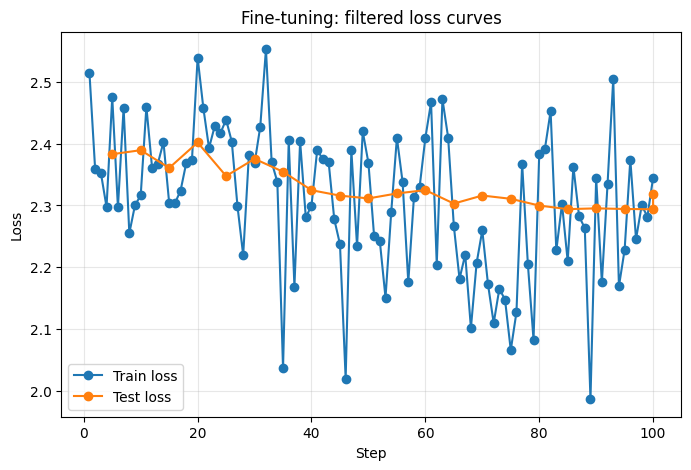

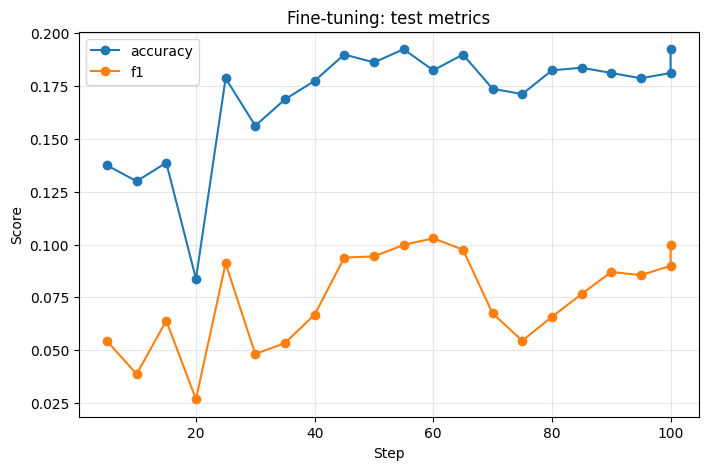

In [40]:
log_df = pd.DataFrame(trainer.state.log_history)

train_logs = log_df.dropna(subset=["loss"]).copy() if "loss" in log_df.columns else pd.DataFrame()
test_logs = log_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in log_df.columns else pd.DataFrame()
summary_logs = log_df.dropna(subset=["train_loss"]).copy() if "train_loss" in log_df.columns else pd.DataFrame()

print("=== Train Logs ===")
if len(train_logs) > 0:
    cols = [
        c for c in ["step", "epoch", "loss", "grad_norm", "learning_rate"]
        if c in train_logs.columns
    ]
    display(train_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Eval Logs ===")
if len(test_logs) > 0:
    cols = [
        c for c in ["step", "epoch", "eval_loss", "eval_accuracy", "eval_f1", "eval_runtime"]
        if c in test_logs.columns
    ]
    display(test_logs[cols].tail(10))
else:
    print("Нет train-логов")

print("\n=== Summary Logs ===")
if len(summary_logs) > 0:
    cols = [
        c for c in ["train_runtime", "train_samples_per_second", "train_steps_per_second", "train_loss", "epoch"]
        if c in summary_logs.columns
    ]
else:
    print("Нет summary-логов")

plt.figure(figsize=(8, 5))

if len(train_logs) > 0:
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="Train loss")

if len(test_logs) > 0:
    plt.plot(test_logs["step"], test_logs["eval_loss"], marker="o", label="Test loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Fine-tuning: filtered loss curves")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

metric_cols = [
    c for c in ["eval_accuracy", "eval_f1"]
    if c in test_logs.columns
]

if len(test_logs) > 0 and len(metric_cols) > 0:
    plt.figure(figsize=(8, 5))

    for col in metric_cols:
        plt.plot(
            test_logs["step"],
            test_logs[col],
            marker="o",
            label=col.replace("eval_", ""),
        )

    plt.xlabel("Step")
    plt.ylabel("Score")
    plt.title("Fine-tuning: test metrics")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
else:
    print("Нет test-метрик для построения графика")

Предсказания модели.

In [42]:
sample_texts = [
    "В Перми скончался 82-летний актер театра и кино Всевлод Авсентьев",
    "Чемпионат мира по футболу закончился победой Румынии",
    "В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров.",
]
inputs = tokenizer(
    sample_texts,
    truncation=True,
    padding=True,
    return_tensors="pt",
).to(model.device)

with torch.no_grad():
    outputs = model(**inputs)
    preds = outputs.logits.argmax(dim=-1).cpu().numpy()

for text, pred in zip(sample_texts, preds):
    print(f"TEXT: {text}")
    print(f"PRED: {id2label[int(pred)]}")
    print()

TEXT: В Перми скончался 82-летний актер театра и кино Всевлод Авсентьев
PRED: gloss

TEXT: Чемпионат мира по футболу закончился победой Румынии
PRED: gloss

TEXT: В 2021 году Microsoft выпустит специальную версию Windows для бюджетных компьютеров.
PRED: science



## Token classification / NER